# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [3]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [4]:
# CREATE Country list of G7 countries using ISO3 Codes
# YOUR CODE HERE g7 = 
g7 = ['CAN', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'USA']

In [5]:
inflation_df = get_wb_data('FP.CPI.TOTL.ZG', g7, 2000, 2022)

# YOUR CODE HERE
inflation_df.head(10)

,countryiso3code,date,value
0,CAN,2022,6.802801
1,CAN,2021,3.395193
2,CAN,2020,0.717000
3,CAN,2019,1.949269
4,CAN,2018,2.268226
5,CAN,2017,1.596884
6,CAN,2016,1.428760
7,CAN,2015,1.125241
8,CAN,2014,1.906636
9,CAN,2013,0.938292


## A.2 Show column names


In [6]:
# YOUR CODE HERE
inflation_df.columns

Index(['countryiso3code', 'date', 'value'], dtype='object')

## A.3 Show unique countries

In [11]:
# YOUR CODE HERE
inflation_df.countryiso3code.unique()

array(['CAN', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'USA'], dtype=object)

# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [24]:
# Rename country and value columns
# YOUR CODE HERE
inflation_df_renamed = inflation_df.rename(columns={'countryiso3code': 'country', 'value': 'inflation'})
inflation_df_renamed.head(5)

,country,date,inflation
0,CAN,2022,6.802801
1,CAN,2021,3.395193
2,CAN,2020,0.717000
3,CAN,2019,1.949269
4,CAN,2018,2.268226


## 1.1 Create new data with only Japan

In [25]:
# Query japan
# YOUR CODE HERE
df_jp = inflation_df.query("countryiso3code == 'JPN'")
df_jp_renamed = df_jp.rename(columns={'countryiso3code': 'country', 'value': 'inflation'})
df_jp_renamed.head(5)

,country,date,inflation
115,JPN,2022,2.497703
116,JPN,2021,-0.233353
117,JPN,2020,-0.024996
118,JPN,2019,0.468776
119,JPN,2018,0.989095


## 1.2 Set index as date, sort index, and drop country column

In [35]:
# Set index 
# YOUR CODE HERE
indexed = df_jp.set_index("date").dropna()
indexed.head(10)

,countryiso3code,value
date,,
2022,JPN,2.497703
2021,JPN,-0.233353
2020,JPN,-0.024996
2019,JPN,0.468776
2018,JPN,0.989095
2017,JPN,0.484200
2016,JPN,-0.127259
2015,JPN,0.795280
2014,JPN,2.759227


In [37]:
# DROP country column
# YOUR CODE HERE 
indexed = indexed.drop(["countryiso3code"], axis='columns')
indexed.head(10)

,value
date,
2022,2.497703
2021,-0.233353
2020,-0.024996
2019,0.468776
2018,0.989095
2017,0.484200
2016,-0.127259
2015,0.795280
2014,2.759227


In [38]:
# Sort index makes it so date is descending
# YOUR CODE HERE 
indexed = indexed.sort_index()
indexed.head(10)

,value
date,
2000,-0.676579
2001,-0.740056
2002,-0.923494
2003,-0.256542
2004,-0.008573
2005,-0.282946
2006,0.249355
2007,0.060039
2008,1.380079


## 1.3 Plot

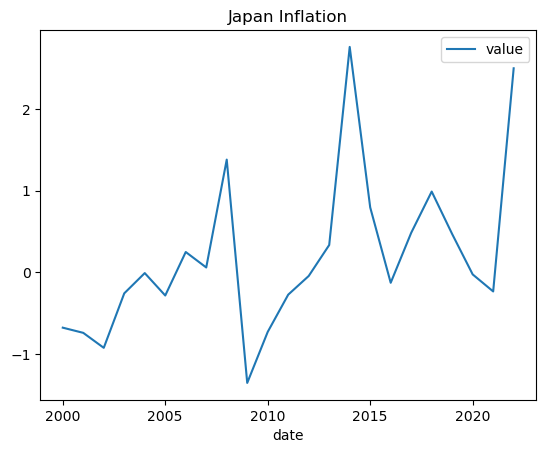

In [39]:
# Your code here
indexed.plot()
plt.title("Japan Inflation");

In [42]:
indexed["value"].describe()

count    23.000000
mean      0.189017
std       0.992928
min      -1.352837
25%      -0.277701
50%      -0.024996
75%       0.476488
max       2.759227
Name: value, dtype: float64

Text(0.5, 1.0, 'Japan Inflation Described')

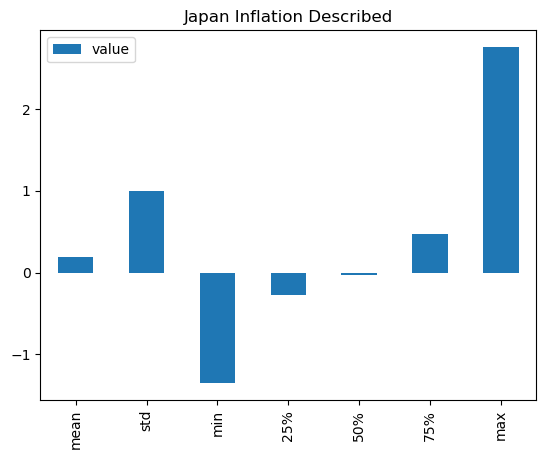

In [44]:
indexed['value'].describe().drop(['count'], axis = 0).to_frame().plot(kind = 'bar')
plt.title("Japan Inflation Described")

# 2. Merging Data
## 2.A Importing data

In [45]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [46]:
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_govt_bond.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [47]:
df_govt_bond.economy.unique()

array(['BR', 'CN', 'HK', 'ID', 'JP', 'KH', 'KR', 'LA', 'MM', 'MY', 'PH',
       'SG', 'TH', 'VN'], dtype=object)

In [78]:
#MAKE SURE YOU query df_govt_bond
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'") #YOUR CODE HERE query VN
df_govt_bond_vn.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
299,VN,1997,Vietnam,NaN,1.000000,0.714286,84.50824,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN
300,VN,1998,Vietnam,NaN,0.888889,1.000000,84.61529,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN


In [79]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_vn = df_gdp.query("economy == 'VN'") #YOUR CODE HERE query VN 
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


## 2.2 Filter gdp_pc_pp and set date as index

In [81]:
df_gdp_vn = df_gdp_vn[['gdp_pc_ppp', 'date']] # YOUR CODE HERE
df_gdp_vn = df_gdp_vn.set_index("date").dropna()
df_gdp_vn.head(5)

,gdp_pc_ppp
date,
1997,1709.896773
1998,1805.815779
1999,1896.989470
2000,2048.363759
2001,2200.020240


In [83]:
df_govt_bond_vn = df_govt_bond_vn[['net_borrow', 'date']] # YOUR CODE HERE
df_govt_bond_vn = df_govt_bond_vn.set_index("date").dropna()
df_govt_bond_vn.head(2)

,net_borrow
date,
1999,0.126
2000,1.582


## 2.3 Merge data

In [91]:
# NOTE I sorted index and drop na

df_merge = pd.merge(df_gdp_vn, df_govt_bond_vn, on='date') # YOUR CODE HERE
df_merge.head(5)

,gdp_pc_ppp,net_borrow
date,,
1999,1896.989470,0.126
2000,2048.363759,1.582
2001,2200.020240,2.038
2002,2353.000468,2.784
2003,2538.163204,2.355


## 2.4 Convert to datetime

In [92]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,gdp_pc_ppp,net_borrow
date,,
1999-01-01,1896.989470,0.126
2000-01-01,2048.363759,1.582


## 2.4 Plot net_borrow

Text(0, 0.5, '% GDP')

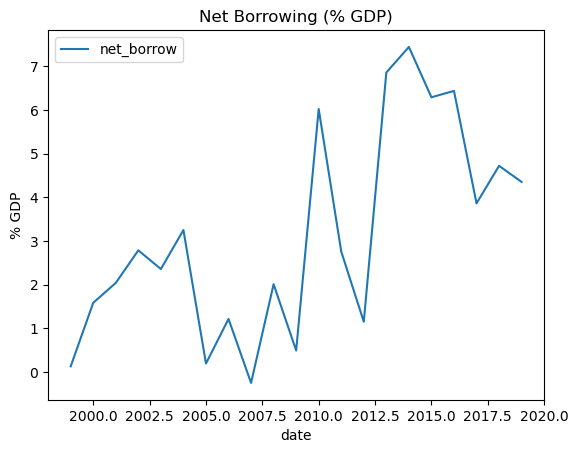

In [110]:
# Your code here
df_govt_bond_vn.plot()

plt.title("Net Borrowing (% GDP)")
plt.ylabel("% GDP")

# 3. Functions

## 3.A Import Data

In [94]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

In [95]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

## 3.1 Create function to conver to datetime

In [132]:
def convert_date(df):
    df['date'] = pd.to_datetime(df['date'], format='%Y').dt.year
    return df


In [133]:
df_merge_all.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


In [134]:
df_merge_all_converted = convert_date(df_merge_all)
df_merge_all_converted.head(10)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
2,BR,1999,Brunei,63432.255561,20692.236087,NaN,60.176555,3.000000,3.000000,7.250000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
3,BR,2000,Brunei,65305.765574,21757.595387,NaN,50.293146,3.000000,3.000000,8.000000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
4,BR,2001,Brunei,67184.354498,22844.964797,NaN,53.633142,3.000000,2.666667,10.625000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
5,BR,2002,Brunei,69510.208532,24104.889135,NaN,53.675763,3.000000,2.500000,11.500000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
6,BR,2003,Brunei,71514.393722,25265.534701,4.435250,50.838985,3.000000,2.500000,11.500000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
7,BR,2004,Brunei,72549.224959,26076.585575,4.456083,46.435854,3.000000,2.500000,11.500000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
8,BR,2005,Brunei,73930.477703,26993.052436,4.494000,40.292105,3.000000,2.500000,11.500000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
9,BR,2006,Brunei,78411.614599,29032.919656,4.458500,34.949935,3.208333,2.500000,11.500000,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

/var/folders/_1/86vrhcd148jb1w47rcyvky8c0000gn/T/ipykernel_37519/2254164380.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])


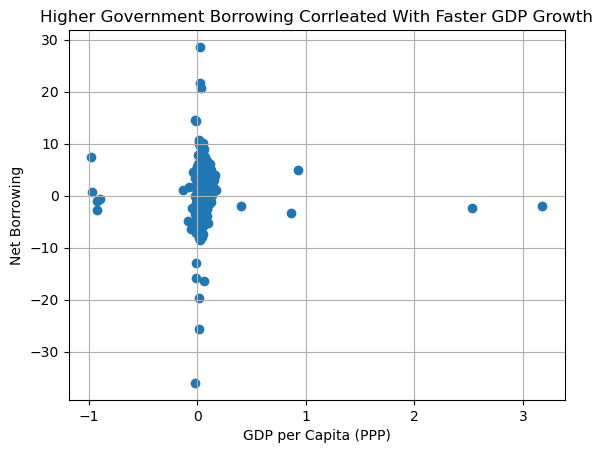

In [147]:
def plot_scatter(x_title, y_title, main_title):
    df_plot = df_merge_all_converted
    
    # Define the columns for x and y
    plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])
    
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(main_title)
    plt.grid(True)
    plt.show()

# Note corrleation does not equal causation :)
plot_scatter('GDP per Capita (PPP)', 'Net Borrowing', 'Higher Government Borrowing Corrleated With Faster GDP Growth')